# 5 GHz + BLE + Power Offline Analysis

This notebook is the offline analysis counterpart to Grafana for the Monad fleet measurement plan. It reads normalized exports from `artifacts/analysis/<run_id>/`, computes thesis-ready statistics, and writes figures/tables back to `artifacts/figures/<run_id>/` and `artifacts/tables/<run_id>/`.

The first pass is intentionally tolerant of missing files. That lets us build the notebook before the pcap/Mimir/eLab export scripts are finished.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## Configuration

Set `RUN_ID` to the folder name under `artifacts/analysis/`. The default points at the latest downloaded experiment-78 dataset. The notebook writes outputs under `artifacts/figures/<run_id>/` and `artifacts/tables/<run_id>/`.

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "AGENTS.md").exists() and (candidate / "src").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root()
RUN_ID = "exp174"

DATASET_DIR = REPO_ROOT / "artifacts" / "analysis" / RUN_ID
FIGURES_DIR = REPO_ROOT / "artifacts" / "figures" / RUN_ID
TABLES_DIR = REPO_ROOT / "artifacts" / "tables" / RUN_ID

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR

PosixPath('/Users/admin/FleetManager/artifacts/analysis/exp174')

## Dataset Contract

Expected files in `DATASET_DIR`:

- `metadata.json`: run metadata such as `run_id`, `experiment_id`, profile, site, and device list.
- `events.ndjson`: agent run events, one JSON object per line.
- `wifi_5g_frames.csv`: one row per captured 802.11 frame after pcap extraction.
- `wifi_5g_channel_schedule.jsonl`: channel dwell log produced by the agent.
- `ble_tx.csv`: one row per BLE advertisement transmission ID.
- `ble_rx.csv`: one row per received BLE advertisement.
- `power_timeseries.csv`: one row per power telemetry sample.
- `command_status.csv`: normalized command outcome rows from evidence bundles.
- `wifi_capture_summary.csv`: per-Pi WIFI_SCAN outcome, including pcap byte count when reported.
- `dataset_summary.json`: preparation-level counts and caveats.

Current repo state can produce pcaps and channel schedules. The pcap-to-CSV extractor is the next implementation step after this notebook contract.

In [3]:
def read_json(path: Path, default=None):
    if not path.exists():
        return default
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)


def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    rows = []
    with path.open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def coerce_time(df: pd.DataFrame, column: str = "timestamp") -> pd.DataFrame:
    if df.empty or column not in df.columns:
        return df
    out = df.copy()
    out[column] = pd.to_datetime(out[column], utc=True, errors="coerce")
    return out


def maybe_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def savefig(name: str):
    png = FIGURES_DIR / f"{name}.png"
    svg = FIGURES_DIR / f"{name}.svg"
    plt.savefig(png, dpi=180, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    return png, svg

In [4]:
metadata = read_json(DATASET_DIR / "metadata.json", default={}) or {}

events_path = DATASET_DIR / "events.ndjson"
if not events_path.exists():
    sample_events = REPO_ROOT / "artifacts" / "output" / "room_mock_216_events.ndjson"
    events_path = sample_events if sample_events.exists() else events_path

events = coerce_time(read_jsonl(events_path), "timestamp")
wifi = coerce_time(read_csv(DATASET_DIR / "wifi_5g_frames.csv"), "timestamp")
schedule = read_jsonl(DATASET_DIR / "wifi_5g_channel_schedule.jsonl")
ble_tx = coerce_time(read_csv(DATASET_DIR / "ble_tx.csv"), "tx_timestamp")
ble_rx = coerce_time(read_csv(DATASET_DIR / "ble_rx.csv"), "rx_timestamp")
power = coerce_time(read_csv(DATASET_DIR / "power_timeseries.csv"), "timestamp")
command_status = coerce_time(read_csv(DATASET_DIR / "command_status.csv"), "timestamp")
wifi_capture_summary = coerce_time(read_csv(DATASET_DIR / "wifi_capture_summary.csv"), "timestamp")
dataset_summary = read_json(DATASET_DIR / "dataset_summary.json", default={}) or {}

wifi = maybe_numeric(wifi, ["channel", "freq_mhz", "bandwidth_mhz", "frame_len", "rssi_dbm"])
schedule = maybe_numeric(schedule, ["channel", "dwell_start_us", "dwell_end_us"])
ble_rx = maybe_numeric(ble_rx, ["rssi_dbm"])
power = maybe_numeric(power, ["core_voltage_v", "pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v", "under_voltage", "cpu_temp_c"])

pd.DataFrame([
    {"stream": "events", "rows": len(events), "path": str(events_path.relative_to(REPO_ROOT)) if events_path.exists() else "missing"},
    {"stream": "wifi_5g_frames", "rows": len(wifi), "path": str((DATASET_DIR / "wifi_5g_frames.csv").relative_to(REPO_ROOT))},
    {"stream": "wifi_schedule", "rows": len(schedule), "path": str((DATASET_DIR / "wifi_5g_channel_schedule.jsonl").relative_to(REPO_ROOT))},
    {"stream": "ble_tx", "rows": len(ble_tx), "path": str((DATASET_DIR / "ble_tx.csv").relative_to(REPO_ROOT))},
    {"stream": "ble_rx", "rows": len(ble_rx), "path": str((DATASET_DIR / "ble_rx.csv").relative_to(REPO_ROOT))},
    {"stream": "power", "rows": len(power), "path": str((DATASET_DIR / "power_timeseries.csv").relative_to(REPO_ROOT))},
    {"stream": "command_status", "rows": len(command_status), "path": str((DATASET_DIR / "command_status.csv").relative_to(REPO_ROOT))},
    {"stream": "wifi_capture_summary", "rows": len(wifi_capture_summary), "path": str((DATASET_DIR / "wifi_capture_summary.csv").relative_to(REPO_ROOT))},
])

,stream,rows,path
0,events,10,artifacts/analysis/exp174/events.ndjson
1,wifi_5g_frames,20509870,artifacts/analysis/exp174/wifi_5g_frames.csv
2,wifi_schedule,820992,artifacts/analysis/exp174/wifi_5g_channel_sche...
3,ble_tx,93427,artifacts/analysis/exp174/ble_tx.csv
4,ble_rx,47670,artifacts/analysis/exp174/ble_rx.csv
5,power,0,artifacts/analysis/exp174/power_timeseries.csv
6,command_status,10,artifacts/analysis/exp174/command_status.csv
7,wifi_capture_summary,5,artifacts/analysis/exp174/wifi_capture_summary...


## Sanity Checks

Before doing statistics, verify coverage and gaps. Gaps usually mean control-plane drops, agent restarts, or export problems.

In [5]:
def coverage_row(name: str, df: pd.DataFrame, ts_col: str = "timestamp") -> dict:
    row = {"stream": name, "rows": len(df), "start": pd.NaT, "end": pd.NaT, "duration_s": np.nan}
    if df.empty or ts_col not in df.columns:
        return row
    ts = pd.to_datetime(df[ts_col], utc=True, errors="coerce").dropna()
    if ts.empty:
        return row
    row["start"] = ts.min()
    row["end"] = ts.max()
    row["duration_s"] = (row["end"] - row["start"]).total_seconds()
    return row


if dataset_summary:
    display(dataset_summary)

coverage = pd.DataFrame([
    coverage_row("events", events),
    coverage_row("wifi", wifi),
    coverage_row("ble_tx", ble_tx, "tx_timestamp"),
    coverage_row("ble_rx", ble_rx, "rx_timestamp"),
    coverage_row("power", power),
])
coverage.to_csv(TABLES_DIR / "coverage.csv", index=False)
coverage

{'ble': {'rx_rows': 47670,
  'rx_rows_by_pi': {'monad-03': 10473,
   'monad-04': 12629,
   'monad-05': 6896,
   'monad-06': 17672},
  'rx_rows_with_adv_id': 22647,
  'rx_rows_with_rssi': 28254,
  'tx_rows': 93427},
 'command_status_by_command_exit': {'ble-advertise-monad-02-20260526T225112Z|exit_0': 1,
  'ble-listen-monad-03-20260526T225112Z|exit_0': 1,
  'ble-listen-monad-04-20260526T225112Z|exit_0': 1,
  'ble-listen-monad-05-20260526T225112Z|exit_0': 1,
  'ble-listen-monad-06-20260526T225112Z|exit_0': 1,
  'wifi-scan-monad-02-20260526T225112Z|exit_0': 1,
  'wifi-scan-monad-03-20260526T225112Z|exit_0': 1,
  'wifi-scan-monad-04-20260526T225112Z|exit_0': 1,
  'wifi-scan-monad-05-20260526T225112Z|exit_0': 1,
  'wifi-scan-monad-06-20260526T225112Z|exit_0': 1},
 'pcaps': {'inputs': 5, 'tshark_available': False},
 'wifi_capture_summary': [{'channels': '',
   'command_id': 'wifi-scan-monad-02-20260526T225112Z',
   'duration_ms': '0',
   'dwell_changes': '',
   'exit_code': '0',
   'message':

,stream,rows,start,end,duration_s
0,events,10,2026-05-26 22:52:25.897296+00:00,2026-05-28 00:51:49.843187+00:00,93563.945891
1,wifi,20509870,2026-05-26 22:52:08.281078+00:00,2026-05-28 00:51:03.102508+00:00,93534.821430
2,ble_tx,93427,2026-05-26 22:52:53.292838+00:00,2026-05-28 00:51:09.710823+00:00,93496.417985
3,ble_rx,47670,NaT,NaT,NaN
4,power,0,NaT,NaT,NaN


In [6]:
def gap_summary(df: pd.DataFrame, ts_col: str, group_col: str | None = None, threshold_s: float = 5.0) -> pd.DataFrame:
    if df.empty or ts_col not in df.columns:
        return pd.DataFrame(columns=["group", "gap_count", "max_gap_s"])
    work = df.copy()
    work[ts_col] = pd.to_datetime(work[ts_col], utc=True, errors="coerce")
    work = work.dropna(subset=[ts_col]).sort_values(ts_col)
    if group_col and group_col in work.columns:
        groups = work.groupby(group_col, dropna=False)
    else:
        groups = [("all", work)]
    rows = []
    for name, part in groups:
        gaps = part[ts_col].diff().dt.total_seconds().dropna()
        rows.append({"group": name, "gap_count": int((gaps > threshold_s).sum()), "max_gap_s": float(gaps.max()) if len(gaps) else 0.0})
    return pd.DataFrame(rows).sort_values(["gap_count", "max_gap_s"], ascending=False)


power_gaps = gap_summary(power, "timestamp", "pi_id", threshold_s=3.0)
wifi_gaps = gap_summary(wifi, "timestamp", "pi_id", threshold_s=3.0)
display(power_gaps.head(10))
display(wifi_gaps.head(10))

,group,gap_count,max_gap_s


,group,gap_count,max_gap_s
1,monad-03,10104,6.427605
4,monad-06,10038,10.546313
0,monad-02,7566,10.666382
2,monad-04,7415,10.563026
3,monad-05,6745,10.614429


## 5 GHz Statistics

These cells compute the exact aggregations requested in the plan once `wifi_5g_frames.csv` exists.

In [7]:
wifi_summary = {}

if not wifi_capture_summary.empty:
    display(wifi_capture_summary)

if wifi.empty:
    print("No wifi_5g_frames.csv yet. Next implementation step: pcap -> normalized CSV extractor using tshark.")
else:
    src_col = "src_mac" if "src_mac" in wifi.columns else None
    wifi_summary["wifi_frame_count"] = int(len(wifi))
    wifi_summary["wifi_distinct_src_macs"] = int(wifi[src_col].nunique()) if src_col else 0
    wifi_summary["wifi_distinct_bssids"] = int(wifi["bssid"].nunique()) if "bssid" in wifi.columns else 0
    wifi_summary["wifi_channels_seen"] = int(wifi["channel"].nunique()) if "channel" in wifi.columns else 0
    pd.Series(wifi_summary)

,timestamp,run_id,pi_id,command_id,exit_code,duration_ms,pcap_bytes,dwell_changes,channels,message,source
0,2026-05-26 22:52:25.897296+00:00,4b39dd58-faba-49cb-b8d0-62fa0d830cad,monad-02,wifi-scan-monad-02-20260526T225112Z,0,0,NaN,NaN,NaN,passive_monitor started async,monad-02__wireless-run-evidence-bundle.synthet...
1,2026-05-27 01:40:53.847286+00:00,c074f31b-b780-4296-81ee-65d693e92dce,monad-03,wifi-scan-monad-03-20260526T225112Z,0,0,NaN,NaN,NaN,passive_monitor started async,monad-03__wireless-run-evidence-bundle.synthet...
2,2026-05-27 01:42:49.475784+00:00,58d743ca-d4dc-4f8a-b14a-a6eac48c23e1,monad-04,wifi-scan-monad-04-20260526T225112Z,0,0,NaN,NaN,NaN,passive_monitor started async,monad-04__wireless-run-evidence-bundle.synthet...
3,2026-05-27 01:39:05.237587+00:00,c1b21814-c5ed-434a-a2c9-02089a9427bc,monad-05,wifi-scan-monad-05-20260526T225112Z,0,0,NaN,NaN,NaN,passive_monitor started async,monad-05__wireless-run-evidence-bundle.synthet...
4,2026-05-27 01:40:31.102944+00:00,abc569d2-47a9-40ac-85b8-6fd79a4929c9,monad-06,wifi-scan-monad-06-20260526T225112Z,0,0,NaN,NaN,NaN,passive_monitor started async,monad-06__wireless-run-evidence-bundle.synthet...


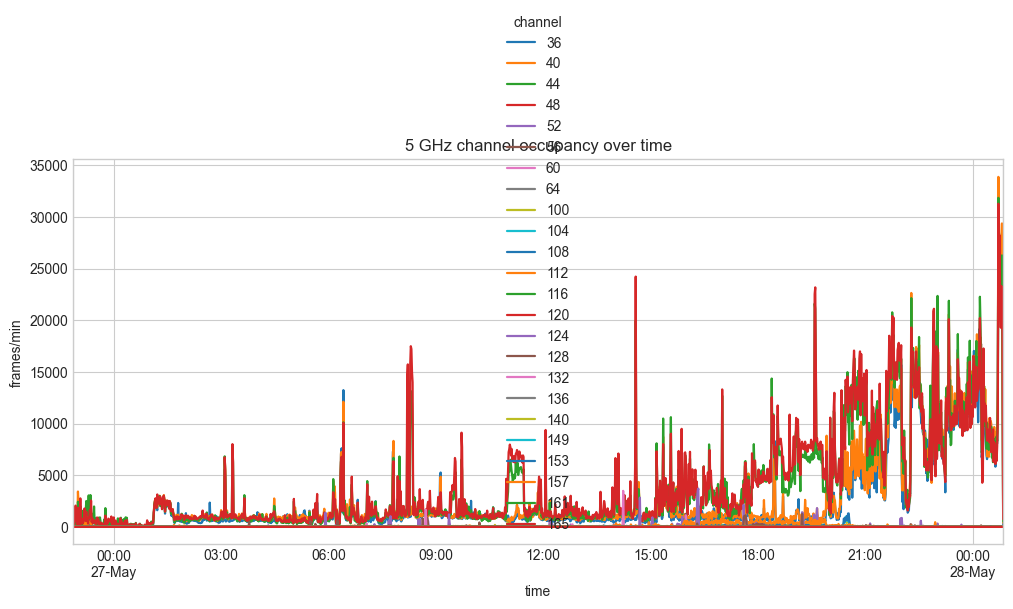

In [8]:
if not wifi.empty and {"channel", "timestamp"}.issubset(wifi.columns):
    work = wifi.dropna(subset=["timestamp", "channel"]).copy()
    work["minute"] = work["timestamp"].dt.floor("min")
    channel_timeline = work.groupby(["minute", "channel"]).size().rename("frames").reset_index()
    channel_pivot = channel_timeline.pivot(index="minute", columns="channel", values="frames").fillna(0)
    channel_pivot.to_csv(TABLES_DIR / "wifi_channel_occupancy_timeline.csv")
    ax = channel_pivot.plot(figsize=(12, 5), linewidth=1.6)
    ax.set_title("5 GHz channel occupancy over time")
    ax.set_xlabel("time")
    ax.set_ylabel("frames/min")
    savefig("wifi_channel_occupancy")
else:
    print("Skipping channel occupancy plot until timestamp + channel columns are available.")

In [9]:
if not wifi.empty and "src_oui" in wifi.columns:
    vendor_counts = wifi.groupby("src_oui", dropna=False)["src_mac"].nunique().rename("distinct_devices").reset_index()
    vendor_counts = vendor_counts.sort_values("distinct_devices", ascending=False)
    vendor_counts.to_csv(TABLES_DIR / "wifi_vendor_counts.csv", index=False)
    intel_devices = vendor_counts[vendor_counts["src_oui"].astype(str).str.contains("intel", case=False, na=False)]["distinct_devices"].sum()
    total_devices = max(1, vendor_counts["distinct_devices"].sum())
    wifi_summary["wifi_percent_intel"] = float(100.0 * intel_devices / total_devices)
    display(vendor_counts.head(20))
else:
    print("Skipping OUI/vendor breakdown until src_oui is available.")

,src_oui,distinct_devices
11735,DA:A1:19,45
5596,68:8F:C9,36
871,12:32:2C,33
9194,AC:F8:CC,33
4524,56:5B:86,28
5574,66:E2:20,28
10452,C2:C4:F9,27
8766,A6:04:50,25
6613,7A:F5:05,23
2516,2E:D1:C6,22


,src_oui,vendor,randomised,frames
13759,NaN,unknown (no addr2),False,18821312
835,10:FE:ED,unknown (10:FE:ED),False,226307
3023,38:43:7D,unknown (38:43:7D),False,205795
2811,34:2C:C4,unknown (34:2C:C4),False,203641
7714,90:5C:44,unknown (90:5C:44),False,146072
5594,68:02:B8,unknown (68:02:B8),False,129810
2336,2C:CF:67,unknown (2C:CF:67),False,115202
9194,AC:F8:CC,unknown (AC:F8:CC),False,89786
4238,52:07:C3,randomised MAC,True,59099
10051,BC:07:1D,unknown (BC:07:1D),False,37569


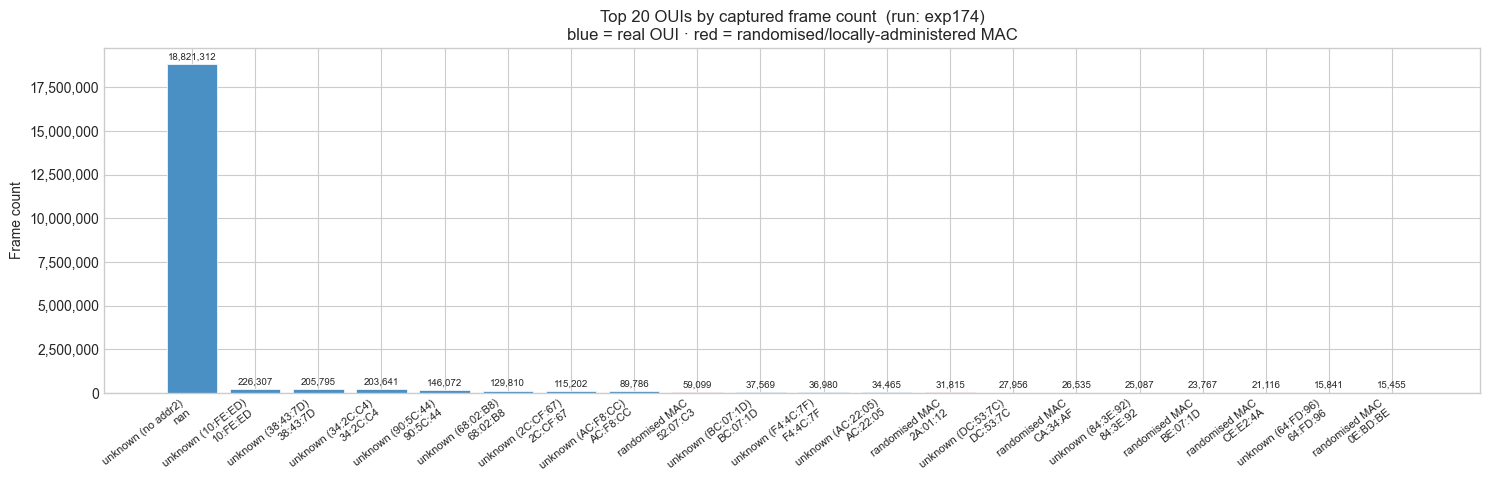

In [10]:
# OUI → vendor name (verified against IEEE OUI database)
def classify_oui(oui):
    """Return (vendor_label, is_randomised) for a given OUI string."""
    if not isinstance(oui, str) or oui == 'nan':
        return 'unknown (no addr2)', False
    first_byte = int(oui.split(':')[0], 16)
    if first_byte & 0x02:   # locally administered = randomised
        return 'randomised MAC', True
    lookup = {
        # Infrastructure / APs
        '34:2c:c4': 'Compal (AP)',
        '90:5c:44': 'Compal (AP)',
        '68:02:b8': 'Compal (AP)',
        '38:43:7d': 'Compal (AP)',
        '10:fe:ed': 'TP-Link (AP)',
        '4c:cf:7c': 'TP-Link (AP)',
        '5c:62:8b': 'TP-Link (AP)',
        'b4:fb:e4': 'Ubiquiti (AP)',
        'e4:38:83': 'Ubiquiti (AP)',
        '18:e8:29': 'Ubiquiti (AP)',
        'ac:f8:cc': 'CommScope (AP)',
        'ac:8b:a9': 'Ubiquiti (AP)',
        'cc:6b:1e': 'CLOUD NET TECH (switch)',
        '64:fd:96': 'Sagemcom (AP)',
        # Client devices
        '78:f5:05': 'Murata (IoT)',
        # Our Pis
        '2c:cf:67': 'Raspberry Pi (our Pi)',
        '24:eb:16': 'Raspberry Pi (our Pi)',
    }
    return lookup.get(oui, f'unknown ({oui})'), False

if not wifi.empty and "src_oui" in wifi.columns:
    fc = (
        wifi.groupby("src_oui", dropna=False)
        .size()
        .rename("frames")
        .reset_index()
        .sort_values("frames", ascending=False)
        .head(20)
    )
    fc["vendor"], fc["randomised"] = zip(*fc["src_oui"].astype(str).map(classify_oui))

    fc.to_csv(TABLES_DIR / "wifi_vendor_frame_counts.csv", index=False)

    colors = ["#e07070" if r else "#4a90c4" for r in fc["randomised"]]
    labels = fc.apply(lambda r: f"{r['vendor']}\n{r['src_oui']}", axis=1)

    fig, ax = plt.subplots(figsize=(15, 5))
    bars = ax.bar(range(len(fc)), fc["frames"], color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(fc)))
    ax.set_xticklabels(labels, rotation=38, ha="right", fontsize=8)
    ax.set_ylabel("Frame count")
    ax.set_title(f"Top 20 OUIs by captured frame count  (run: {RUN_ID})\n"
                 f"blue = real OUI · red = randomised/locally-administered MAC")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, fc["frames"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + fc["frames"].max()*0.008,
                f"{int(val):,}", ha="center", va="bottom", fontsize=7)
    plt.tight_layout()
    savefig("wifi_vendor_frame_counts")
    display(fc[["src_oui", "vendor", "randomised", "frames"]])
else:
    print("No src_oui column available.")


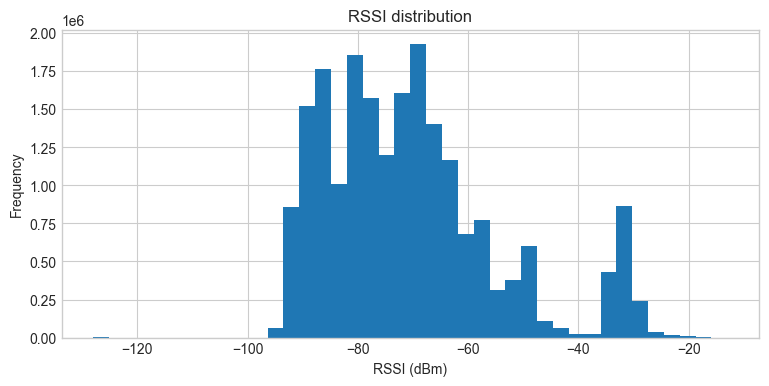

In [11]:
if not wifi.empty and "rssi_dbm" in wifi.columns:
    ax = wifi["rssi_dbm"].dropna().plot(kind="hist", bins=40, figsize=(9, 4))
    ax.set_title("RSSI distribution")
    ax.set_xlabel("RSSI (dBm)")
    savefig("wifi_rssi_distribution")
else:
    print("Skipping RSSI distribution until rssi_dbm is available.")

,frame_type,frames
0,ctrl,13363702
1,NaN,5757671
2,mgmt,1243018
3,data,145479


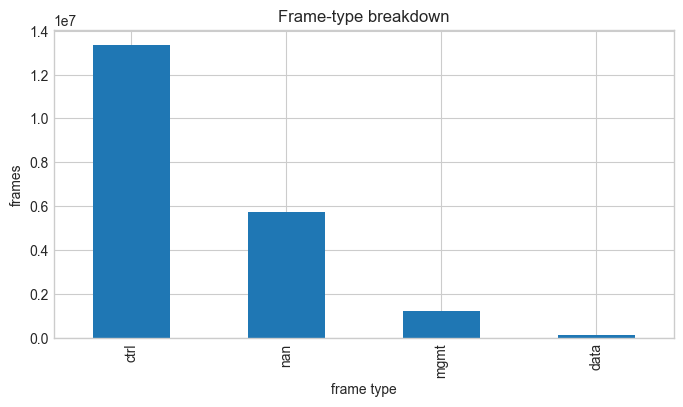

In [12]:
if not wifi.empty and "frame_type" in wifi.columns:
    frame_types = wifi["frame_type"].value_counts(dropna=False).rename_axis("frame_type").reset_index(name="frames")
    frame_types.to_csv(TABLES_DIR / "wifi_frame_type_breakdown.csv", index=False)
    ax = frame_types.plot(kind="bar", x="frame_type", y="frames", legend=False, figsize=(8, 4))
    ax.set_title("Frame-type breakdown")
    ax.set_xlabel("frame type")
    ax.set_ylabel("frames")
    savefig("wifi_frame_type_breakdown")
    display(frame_types)
else:
    print("Skipping frame-type breakdown until frame_type is available.")

In [13]:
if not wifi.empty and {"bssid", "ssid", "channel"}.issubset(wifi.columns):
    ap_inventory = (
        wifi.dropna(subset=["bssid"])
        .groupby(["bssid", "ssid", "channel"], dropna=False)
        .agg(frames=("bssid", "size"), median_rssi_dbm=("rssi_dbm", "median") if "rssi_dbm" in wifi.columns else ("bssid", "size"))
        .reset_index()
        .sort_values("frames", ascending=False)
    )
    ap_inventory.to_csv(TABLES_DIR / "wifi_ap_inventory.csv", index=False)
    display(ap_inventory.head(30))
else:
    print("Skipping AP inventory until bssid + ssid + channel columns are available.")

,bssid,ssid,channel,frames,median_rssi_dbm
347,34:2c:c4:9b:85:69,NaN,40,280708,-62.0
139,10:fe:ed:3b:28:10,NaN,48,253161,-76.0
413,38:43:7d:ef:e8:15,NaN,36,144527,-84.0
735,68:02:b8:4c:ce:f2,NaN,40,136856,-87.0
1125,ac:f8:cc:07:93:65,NaN,112,80542,-89.0
978,90:5c:44:f7:ef:09,NaN,36,72320,-88.0
974,90:5c:44:af:f2:d4,NaN,40,51257,-89.0
1504,f4:4c:7f:df:5e:58,NaN,124,40911,-92.0
273,2a:01:12:5d:a2:7a,NaN,40,39199,-89.0
1097,ac:22:05:af:7b:ad,NaN,40,34441,-91.0


## Top-4 Closest APs: Behaviour Over Time

We pick the **four closest APs** in the lab by ranking BSSIDs (beacons only, ≥1 000 beacons each) on
**90th-percentile RSSI**. P90 is a better proxy for "how loud is this AP when the sniffer is dwelling
on its primary channel" than the median — the median is dragged down by adjacent-channel captures.

For each AP we then look at:

1. **RSSI timeline** – rolling median + P10–P90 band per 5-min bin. Reveals AP power changes,
   moments where the AP went dark, and antenna/person-blockage events.
2. **Beacon rate over time** – beacons/minute per AP, 15-min bins. Steady = AP up and reachable;
   sudden dip to zero = AP down or sniffer not reaching that channel.
3. **Inferred primary channel over time** – per AP and 30-min bin we pick the capture channel
   with the **highest mean RSSI**. Beacons are transmitted only on the primary 20 MHz, so the
   strongest-RSSI capture channel for a stationary AP must be its current primary. If the line
   shifts, the AP changed channel.
4. **Per-AP channel × time heatmap** – beacon count by capture channel and 30-min bin. Shows
   the AP's spectral footprint and any channel re-tuning.

In [14]:
# ── Identify the 4 closest APs and prepare a per-AP frame ──
top4_aps = pd.DataFrame()
beacons = pd.DataFrame()

if wifi.empty or "bssid" not in wifi.columns or "frame_subtype" not in wifi.columns:
    print("Skipping closest-AP analysis: wifi data unavailable.")
else:
    b = wifi.dropna(subset=["bssid", "rssi_dbm", "timestamp"]).copy()
    b = b[b["frame_subtype"].astype(str).str.lower().eq("beacon")]
    b["bssid"] = b["bssid"].astype(str).str.lower()
    rank = (
        b.groupby("bssid")
        .agg(beacons=("rssi_dbm", "size"),
             median_rssi=("rssi_dbm", "median"),
             p90_rssi=("rssi_dbm", lambda s: float(s.quantile(0.9))),
             channels_seen=("channel", lambda s: sorted({int(x) for x in s.dropna()})))
        .reset_index()
    )
    rank = rank[rank["beacons"] >= 1000].sort_values("p90_rssi", ascending=False)

    top4_aps = rank.head(4).reset_index(drop=True)
    top4_aps.to_csv(TABLES_DIR / "wifi_top4_closest_aps.csv", index=False)
    print("Top-4 closest APs (ranked by P90 RSSI):")
    display(top4_aps)

    bssid_keep = set(top4_aps["bssid"])
    beacons = b[b["bssid"].isin(bssid_keep)].copy()
    beacons["timestamp"] = pd.to_datetime(beacons["timestamp"], utc=True, errors="coerce")
    beacons = beacons.dropna(subset=["timestamp"]).sort_values("timestamp")
    print(f"Beacons retained for the 4 APs: {len(beacons):,}")


Top-4 closest APs (ranked by P90 RSSI):


,bssid,beacons,median_rssi,p90_rssi,channels_seen
0,34:2c:c4:9b:85:69,175432,-61.0,-27.0,"[40, 104]"
1,10:fe:ed:3b:28:10,171203,-76.0,-48.0,[48]
2,68:02:b8:4c:ce:f2,124830,-87.0,-63.0,[40]
3,38:43:7d:ef:e8:15,135624,-84.0,-74.0,[36]


Beacons retained for the 4 APs: 607,089


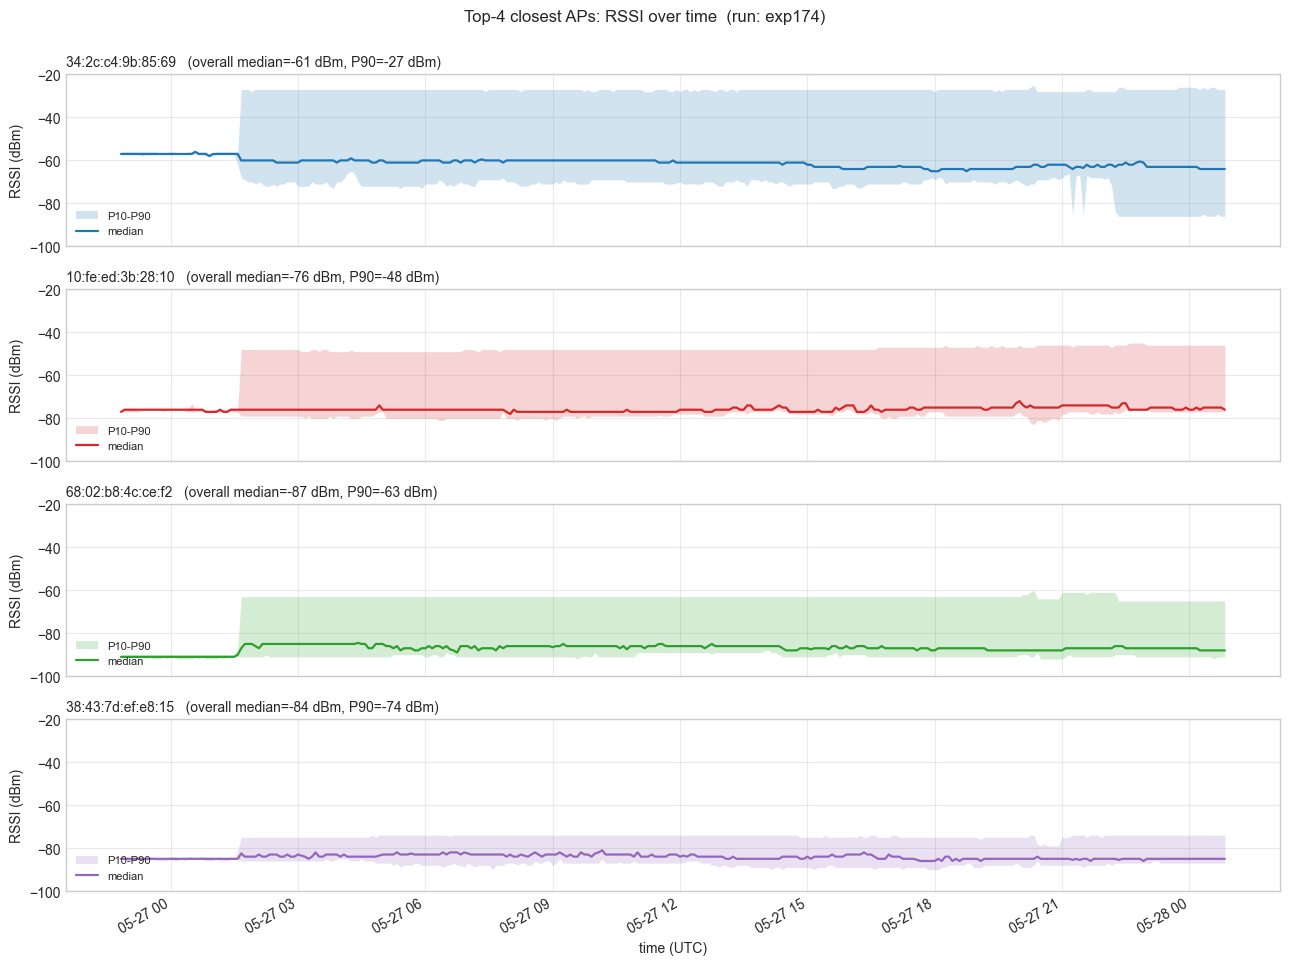

In [15]:
# ── Graph A: RSSI timeline per AP (5-min rolling median + P10-P90 band) ──
if not beacons.empty:
    work = beacons.copy()
    work["bin"] = work["timestamp"].dt.floor("5min")
    agg = (
        work.groupby(["bssid", "bin"])["rssi_dbm"]
        .agg(p10=lambda s: float(s.quantile(0.10)),
             p50=lambda s: float(s.quantile(0.50)),
             p90=lambda s: float(s.quantile(0.90)),
             n="size")
        .reset_index()
    )
    agg.to_csv(TABLES_DIR / "wifi_top4_rssi_timeline.csv", index=False)

    bssids = list(top4_aps["bssid"])
    fig, axes = plt.subplots(len(bssids), 1, figsize=(13, 2.4 * len(bssids)), sharex=True)
    if len(bssids) == 1:
        axes = [axes]
    palette = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
    for ax, bssid, color in zip(axes, bssids, palette):
        part = agg[agg["bssid"] == bssid].sort_values("bin")
        if part.empty:
            ax.set_visible(False); continue
        ax.fill_between(part["bin"], part["p10"], part["p90"], color=color, alpha=0.20, lw=0,
                        label="P10-P90")
        ax.plot(part["bin"], part["p50"], color=color, linewidth=1.6, label="median")
        ax.set_ylabel("RSSI (dBm)")
        ax.set_ylim(-100, -20)
        ax.grid(True, alpha=0.4)
        median = float(top4_aps.loc[top4_aps["bssid"] == bssid, "median_rssi"].iloc[0])
        p90 = float(top4_aps.loc[top4_aps["bssid"] == bssid, "p90_rssi"].iloc[0])
        ax.set_title(f"{bssid}   (overall median={median:.0f} dBm, P90={p90:.0f} dBm)",
                     loc="left", fontsize=10)
        ax.legend(loc="lower left", fontsize=8)
    axes[-1].set_xlabel("time (UTC)")
    fig.suptitle(f"Top-4 closest APs: RSSI over time  (run: {RUN_ID})", y=1.001)
    fig.autofmt_xdate()
    plt.tight_layout()
    savefig("wifi_top4_rssi_timeline")
else:
    print("Skipping RSSI timeline – no beacons for top-4 APs.")


bssid,34:2c:c4:9b:85:69,10:fe:ed:3b:28:10,68:02:b8:4c:ce:f2,38:43:7d:ef:e8:15
count,105.0,105.0,105.0,105.0
mean,1670.8,1630.5,1188.9,1291.7
std,487.9,465.8,331.2,350.5
min,191.0,191.0,176.0,181.0
25%,1804.0,1793.0,1187.0,1354.0
50%,1812.0,1807.0,1307.0,1440.0
75%,1823.0,1815.0,1383.0,1450.0
max,2148.0,1834.0,1444.0,1520.0


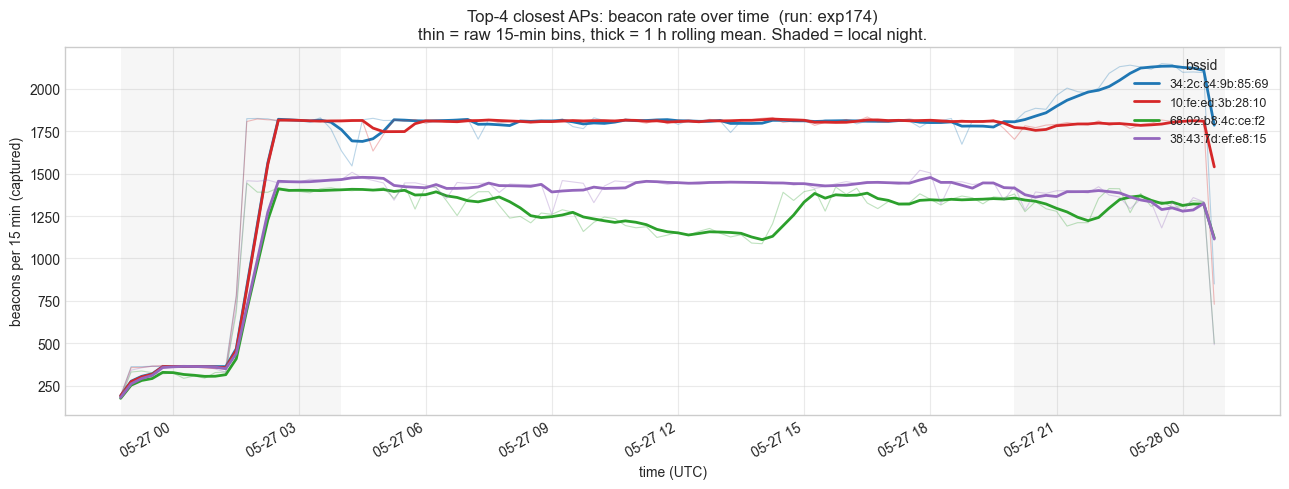

In [16]:
# ── Graph B: Beacon rate per AP over time (15-min bins) ──
if not beacons.empty:
    work = beacons.copy()
    work["bin"] = work["timestamp"].dt.floor("15min")
    rate = work.groupby(["bin", "bssid"]).size().rename("beacons").reset_index()
    pivot = rate.pivot(index="bin", columns="bssid", values="beacons").fillna(0).sort_index()
    pivot = pivot.reindex(columns=list(top4_aps["bssid"]))
    pivot.to_csv(TABLES_DIR / "wifi_top4_beacon_rate.csv")

    fig, ax = plt.subplots(figsize=(13, 5))
    palette = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
    for col, color in zip(pivot.columns, palette):
        rolled = pivot[col].rolling(4, min_periods=1).mean()  # 1 h smoothing
        ax.plot(pivot.index, pivot[col], color=color, alpha=0.30, linewidth=0.8)
        ax.plot(pivot.index, rolled, color=color, linewidth=2.0, label=col)

    # Shade local night (Europe/Bratislava)
    _LOCAL_TZ = "Europe/Bratislava"
    local_idx = pivot.index.tz_convert(_LOCAL_TZ)
    in_night = (local_idx.hour >= 22) | (local_idx.hour < 6)
    for ts, night in zip(pivot.index, in_night):
        if night:
            ax.axvspan(ts, ts + pd.Timedelta("15min"), color="#222", alpha=0.04, lw=0)

    ax.set_title(f"Top-4 closest APs: beacon rate over time  (run: {RUN_ID})\n"
                 f"thin = raw 15-min bins, thick = 1 h rolling mean. Shaded = local night.")
    ax.set_xlabel("time (UTC)")
    ax.set_ylabel("beacons per 15 min (captured)")
    ax.grid(True, alpha=0.4)
    ax.legend(title="bssid", loc="upper right", fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    savefig("wifi_top4_beacon_rate")
    display(pivot.describe().round(1))
else:
    print("Skipping beacon rate – no beacons for top-4 APs.")


,bssid,distinct_primary_channels,primary_channel_changes
0,34:2c:c4:9b:85:69,1,0
1,10:fe:ed:3b:28:10,1,0
2,68:02:b8:4c:ce:f2,1,0
3,38:43:7d:ef:e8:15,1,0


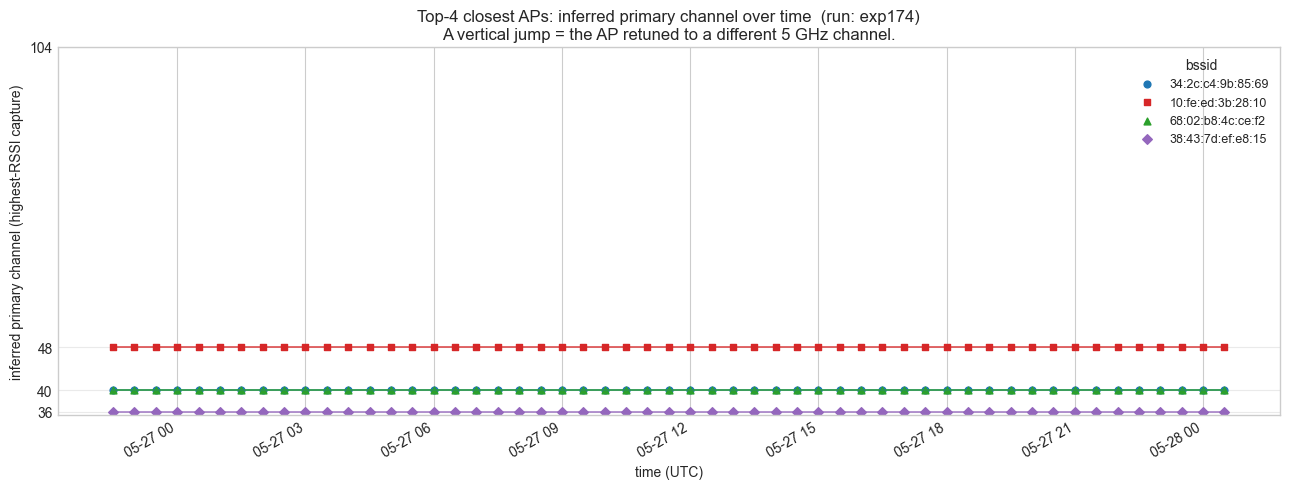

In [17]:
# ── Graph C: Inferred primary channel over time per AP (channel-change detection) ──
if not beacons.empty:
    work = beacons.dropna(subset=["channel"]).copy()
    work["channel"] = work["channel"].astype(int)
    work["bin"] = work["timestamp"].dt.floor("30min")

    # For each (bssid, bin, channel): mean RSSI + beacon count
    cell_stats = (
        work.groupby(["bssid", "bin", "channel"])
        .agg(mean_rssi=("rssi_dbm", "mean"), beacons=("rssi_dbm", "size"))
        .reset_index()
    )
    # Pick the channel with highest mean RSSI per (bssid, bin) — that is the AP's primary
    cell_stats = cell_stats.sort_values(["bssid", "bin", "mean_rssi"], ascending=[True, True, False])
    primary = cell_stats.drop_duplicates(["bssid", "bin"], keep="first").rename(
        columns={"channel": "primary_channel", "mean_rssi": "primary_mean_rssi"}
    )
    primary.to_csv(TABLES_DIR / "wifi_top4_primary_channel_timeline.csv", index=False)

    bssids = list(top4_aps["bssid"])
    fig, ax = plt.subplots(figsize=(13, 5))
    palette = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
    markers = ["o", "s", "^", "D"]
    for bssid, color, mk in zip(bssids, palette, markers):
        part = primary[primary["bssid"] == bssid].sort_values("bin")
        if part.empty:
            continue
        ax.step(part["bin"], part["primary_channel"], where="post",
                color=color, linewidth=1.4, alpha=0.7)
        ax.scatter(part["bin"], part["primary_channel"],
                   color=color, marker=mk, s=24, label=bssid)
    # Show all 5 GHz channels on Y
    all_chans = sorted(work["channel"].unique())
    ax.set_yticks(all_chans)
    ax.set_yticklabels([str(c) for c in all_chans])
    ax.set_xlabel("time (UTC)")
    ax.set_ylabel("inferred primary channel (highest-RSSI capture)")
    ax.set_title(f"Top-4 closest APs: inferred primary channel over time  (run: {RUN_ID})\n"
                 f"A vertical jump = the AP retuned to a different 5 GHz channel.")
    ax.grid(True, axis="y", alpha=0.4)
    ax.legend(title="bssid", loc="upper right", fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    savefig("wifi_top4_primary_channel")

    # Count distinct primary channels per AP and report channel-change events
    changes = (
        primary.sort_values(["bssid", "bin"])
        .groupby("bssid")["primary_channel"]
        .agg(lambda s: int((s.diff().fillna(0) != 0).sum()))
        .rename("primary_channel_changes")
        .reset_index()
    )
    distinct = (
        primary.groupby("bssid")["primary_channel"]
        .nunique().rename("distinct_primary_channels").reset_index()
    )
    summary = top4_aps[["bssid"]].merge(distinct, on="bssid").merge(changes, on="bssid")
    summary.to_csv(TABLES_DIR / "wifi_top4_channel_change_summary.csv", index=False)
    display(summary)
else:
    print("Skipping channel-change graph – no beacons for top-4 APs.")


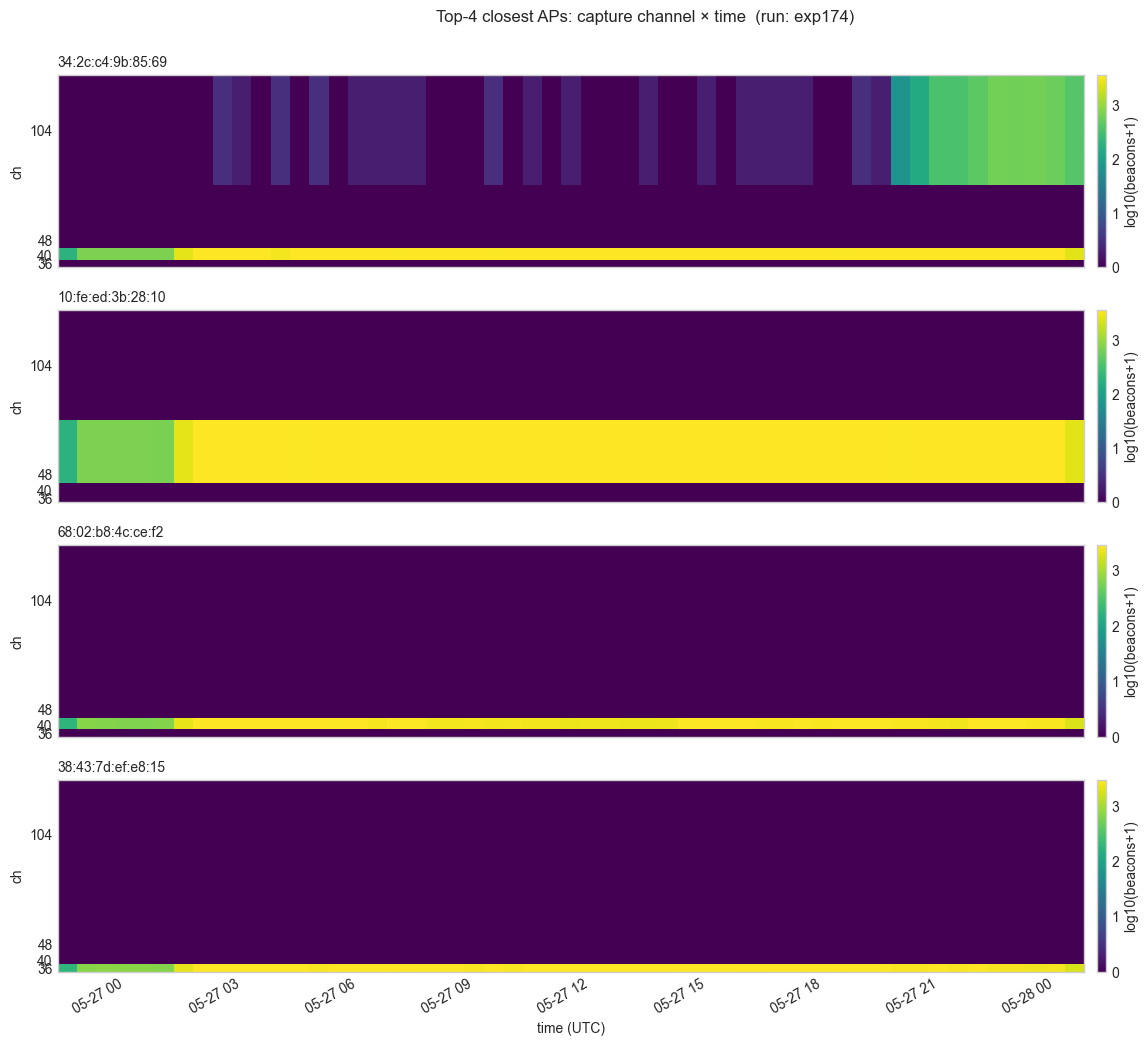

In [18]:
# ── Graph D: Per-AP channel × time beacon-count heatmap ──
if not beacons.empty:
    work = beacons.dropna(subset=["channel"]).copy()
    work["channel"] = work["channel"].astype(int)
    work["bin"] = work["timestamp"].dt.floor("30min")
    all_chans = sorted(work["channel"].unique())

    bssids = list(top4_aps["bssid"])
    fig, axes = plt.subplots(len(bssids), 1, figsize=(13, 2.6 * len(bssids)), sharex=True)
    if len(bssids) == 1:
        axes = [axes]

    for ax, bssid in zip(axes, bssids):
        part = work[work["bssid"] == bssid]
        if part.empty:
            ax.set_visible(False); continue
        mat = (
            part.groupby(["channel", "bin"]).size().rename("beacons").reset_index()
            .pivot(index="channel", columns="bin", values="beacons")
            .reindex(index=all_chans)
            .sort_index(axis=1)
            .fillna(0)
        )
        if mat.empty:
            ax.set_visible(False); continue
        # log scale to bring out adjacent-channel bleed alongside primary
        with np.errstate(divide="ignore"):
            mat_log = np.log10(mat.values + 1)
        x = mat.columns.to_numpy()
        y = mat.index.to_numpy()
        im = ax.pcolormesh(x, y, mat_log, cmap="viridis", shading="nearest")
        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label("log10(beacons+1)")
        ax.set_ylabel("ch")
        ax.set_yticks(all_chans)
        ax.set_title(bssid, loc="left", fontsize=10)

    axes[-1].set_xlabel("time (UTC)")
    fig.suptitle(f"Top-4 closest APs: capture channel × time  (run: {RUN_ID})", y=1.001)
    fig.autofmt_xdate()
    plt.tight_layout()
    savefig("wifi_top4_channel_time_heatmap")
else:
    print("Skipping channel/time heatmap – no beacons for top-4 APs.")


## BLE Statistics

The main join key is `adv_id`: one transmitter event can have multiple receiver events from different Pis.

In [19]:
ble_summary = {}

if ble_tx.empty and ble_rx.empty:
    print("No BLE tx/rx CSVs yet. Scenario B tx logs already exist in the agent; phone/Pi receiver export still needs normalization.")
elif "adv_id" not in ble_rx.columns:
    print("BLE receiver data must include adv_id before cross-correlation is possible.")
else:
    ble_summary["ble_rx_count"] = int(len(ble_rx))
    ble_summary["ble_distinct_adv_ids_rx"] = int(ble_rx["adv_id"].nunique())
    if not ble_tx.empty and "adv_id" in ble_tx.columns:
        joined = ble_rx.merge(ble_tx, on="adv_id", how="left", suffixes=("_rx", "_tx"))
        if {"rx_timestamp", "tx_timestamp"}.issubset(joined.columns):
            joined["rx_timestamp"] = pd.to_datetime(joined["rx_timestamp"], utc=True, errors="coerce")
            joined["tx_timestamp"] = pd.to_datetime(joined["tx_timestamp"], utc=True, errors="coerce")
            joined["rx_minus_tx_ms"] = (joined["rx_timestamp"] - joined["tx_timestamp"]).dt.total_seconds() * 1000.0
        joined.to_csv(TABLES_DIR / "ble_joined_tx_rx.csv", index=False)
        display(joined.head(20))
    display(pd.Series(ble_summary))

,adv_id,rx_timestamp,rx_pi_id,device_mac,device_name,rssi_dbm,event_type,event_index,source_rx,tx_timestamp,tx_pi_id,seq,monotonic_us,source_tx,rx_minus_tx_ms
0,NaN,NaT,monad-03,73:A6:1F:7B:39:34,73-A6-1F-7B-39-34,NaN,NEW,0,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
1,NaN,NaT,monad-03,7E:81:DA:09:D7:0E,7E-81-DA-09-D7-0E,NaN,NEW,1,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
2,NaN,NaT,monad-03,64:A5:97:C1:44:19,64-A5-97-C1-44-19,NaN,NEW,2,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
3,NaN,NaT,monad-03,7A:5E:34:CD:AB:94,7A-5E-34-CD-AB-94,NaN,NEW,3,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
4,NaN,NaT,monad-03,64:CC:13:A3:A2:4B,64-CC-13-A3-A2-4B,NaN,NEW,4,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
5,monad-02-00001e8d,NaT,monad-03,2C:CF:67:80:F5:DA,monad-02-00001e8d,NaN,NEW,5,monad-03__wireless-run-evidence-bundle.synthet...,2026-05-27 01:03:19.199982+00:00,monad-02,7821.0,1.631771e+10,monad-02__wireless-run-evidence-bundle.synthet...,NaN
6,NaN,NaT,monad-03,4F:DB:70:C5:EF:CD,4F-DB-70-C5-EF-CD,NaN,NEW,6,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
7,NaN,NaT,monad-03,7E:81:DA:09:D7:0E,7E-81-DA-09-D7-0E,-74.0,RSSI,7,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
8,NaN,NaT,monad-03,7A:5E:34:CD:AB:94,7A-5E-34-CD-AB-94,-67.0,RSSI,8,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN
9,NaN,NaT,monad-03,73:A6:1F:7B:39:34,73-A6-1F-7B-39-34,-65.0,RSSI,9,monad-03__wireless-run-evidence-bundle.synthet...,NaT,NaN,NaN,NaN,NaN,NaN


ble_rx_count               47670
ble_distinct_adv_ids_rx    10226
dtype: int64

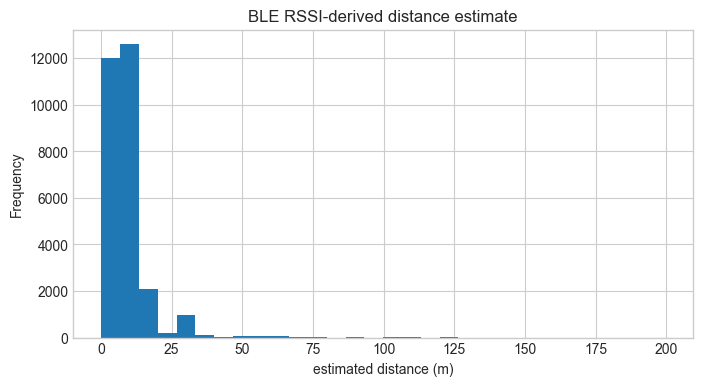

In [20]:
TX_POWER_AT_1M_DBM = -59.0
PATH_LOSS_EXPONENT = 2.0

if not ble_rx.empty and "rssi_dbm" in ble_rx.columns:
    ble_rx_dist = ble_rx.copy()
    ble_rx_dist["distance_m_est"] = 10 ** ((TX_POWER_AT_1M_DBM - ble_rx_dist["rssi_dbm"]) / (10 * PATH_LOSS_EXPONENT))
    ble_rx_dist.to_csv(TABLES_DIR / "ble_rssi_distance_estimates.csv", index=False)
    ax = ble_rx_dist["distance_m_est"].replace([np.inf, -np.inf], np.nan).dropna().plot(kind="hist", bins=30, figsize=(8, 4))
    ax.set_title("BLE RSSI-derived distance estimate")
    ax.set_xlabel("estimated distance (m)")
    savefig("ble_distance_estimate_distribution")
else:
    print("Skipping BLE path-loss estimate until rssi_dbm is available.")

## BLE Environmental Activity Timeline (monad-02 excluded)

`ble_rx.csv` rows from `bluetoothctl scan` do not carry per-event timestamps. To still produce
time-of-day plots, we use **monad-02's broadcasts as time anchors**: every receiver Pi sees a
steady stream of `monad-02-XXXXXX` advertisements whose `tx_timestamp` is known from
`ble_tx.csv`. For each receiver Pi we sort rx events by `event_index`, then linearly interpolate
a `rx_ts_est` for events between anchors. After that we **drop every row whose `device_mac` is
monad-02's HCI address (`2C:CF:67:80:F5:DA`)** so the figures show only the ambient/environmental
BLE devices in the lab during the ~26 h experiment.

Caveat: the interpolation assumes event_index advances roughly linearly with time inside each Pi.
That is a good approximation because monad-02 broadcast at a fixed cadence and the anchors are
dense (~5k+ per receiver), but a single rx_ts_est should not be trusted to better than ~1 s.

In [21]:
MONAD02_BLE_MAC = "2C:CF:67:80:F5:DA"
LOCAL_TZ = "Europe/Bratislava"  # used only for the "hour of day" axis
EPOCH = pd.Timestamp("1970-01-01", tz="UTC")

ble_env = pd.DataFrame()
ble_anchor_summary = pd.DataFrame()

if ble_rx.empty or ble_tx.empty or "adv_id" not in ble_rx.columns or "adv_id" not in ble_tx.columns:
    print("BLE rx/tx data unavailable - timeline section will be skipped.")
else:
    rx = ble_rx.copy()
    rx["event_index"] = pd.to_numeric(rx["event_index"], errors="coerce")

    tx_anchor = (
        ble_tx[["adv_id", "tx_timestamp"]]
        .dropna(subset=["adv_id"])
        .copy()
    )
    tx_anchor["tx_timestamp"] = pd.to_datetime(tx_anchor["tx_timestamp"], utc=True, errors="coerce")
    tx_anchor = tx_anchor.dropna(subset=["tx_timestamp"]).drop_duplicates("adv_id")

    rx = rx.merge(tx_anchor, on="adv_id", how="left")
    rx = rx.dropna(subset=["event_index", "rx_pi_id"]).sort_values(["rx_pi_id", "event_index"])

    def _to_epoch_seconds(series):
        ts = pd.to_datetime(series, utc=True, errors="coerce")
        secs = (ts - EPOCH).dt.total_seconds().to_numpy(copy=True)
        secs[ts.isna().to_numpy()] = np.nan
        return secs

    def _interp_pi(group):
        idx = group["event_index"].to_numpy(dtype=float)
        secs = _to_epoch_seconds(group["tx_timestamp"])
        mask = ~np.isnan(secs)
        if mask.sum() >= 2:
            secs = np.interp(idx, idx[mask], secs[mask])
        elif mask.sum() == 1:
            secs = np.full_like(idx, secs[mask][0], dtype=float)
        else:
            secs = np.full_like(idx, np.nan, dtype=float)
        out = group.copy()
        out["rx_ts_est"] = pd.to_datetime(secs, unit="s", utc=True, errors="coerce")
        return out

    rx = pd.concat([_interp_pi(g) for _, g in rx.groupby("rx_pi_id", sort=False)], ignore_index=True)

    monad02_mask = rx["device_mac"].astype(str).str.upper().eq(MONAD02_BLE_MAC)
    ble_env = rx.loc[~monad02_mask].dropna(subset=["rx_ts_est"]).copy()
    ble_env["rx_ts_est_local"] = ble_env["rx_ts_est"].dt.tz_convert(LOCAL_TZ)
    ble_env["hour_local"] = ble_env["rx_ts_est_local"].dt.hour
    ble_env["rssi_dbm"] = pd.to_numeric(ble_env["rssi_dbm"], errors="coerce")

    ble_anchor_summary = (
        rx.assign(anchored=rx["tx_timestamp"].notna())
        .groupby("rx_pi_id")
        .agg(rx_rows=("event_index", "size"),
             monad02_rows=("device_mac", lambda s: int((s.astype(str).str.upper() == MONAD02_BLE_MAC).sum())),
             anchors=("anchored", "sum"))
        .reset_index()
    )
    ble_anchor_summary["env_rows"] = ble_anchor_summary["rx_rows"] - ble_anchor_summary["monad02_rows"]

    ble_env.to_csv(TABLES_DIR / "ble_env_with_estimated_timestamps.csv", index=False)
    print(f"Total rx rows considered:        {len(rx):,}")
    print(f"Removed as monad-02 broadcasts:  {int(monad02_mask.sum()):,}")
    print(f"Environmental rows kept:         {len(ble_env):,}")
    print(f"Time range covered (UTC):        {ble_env['rx_ts_est'].min()}  →  {ble_env['rx_ts_est'].max()}")
    display(ble_anchor_summary)


Total rx rows considered:        47,670
Removed as monad-02 broadcasts:  23,189
Environmental rows kept:         24,481
Time range covered (UTC):        2026-05-27 01:03:19.199981928+00:00  →  2026-05-28 00:51:07.709028959+00:00


,rx_pi_id,rx_rows,monad02_rows,anchors,env_rows
0,monad-03,10473,1597,1586,8876
1,monad-04,12629,8903,8893,3726
2,monad-05,6896,4317,4297,2579
3,monad-06,17672,8372,7871,9300


rx_pi_id,monad-03,monad-04,monad-05,monad-06
hour_utc,,,,
2026-05-27 17:00:00+00:00,1425.0,166.0,85.0,229.0
2026-05-27 18:00:00+00:00,3.0,165.0,104.0,265.0
2026-05-27 19:00:00+00:00,44.0,89.0,43.0,446.0
2026-05-27 20:00:00+00:00,977.0,181.0,187.0,1106.0
2026-05-27 21:00:00+00:00,2048.0,198.0,377.0,1178.0
2026-05-27 22:00:00+00:00,0.0,182.0,169.0,957.0
2026-05-27 23:00:00+00:00,0.0,212.0,49.0,438.0
2026-05-28 00:00:00+00:00,0.0,152.0,4.0,245.0


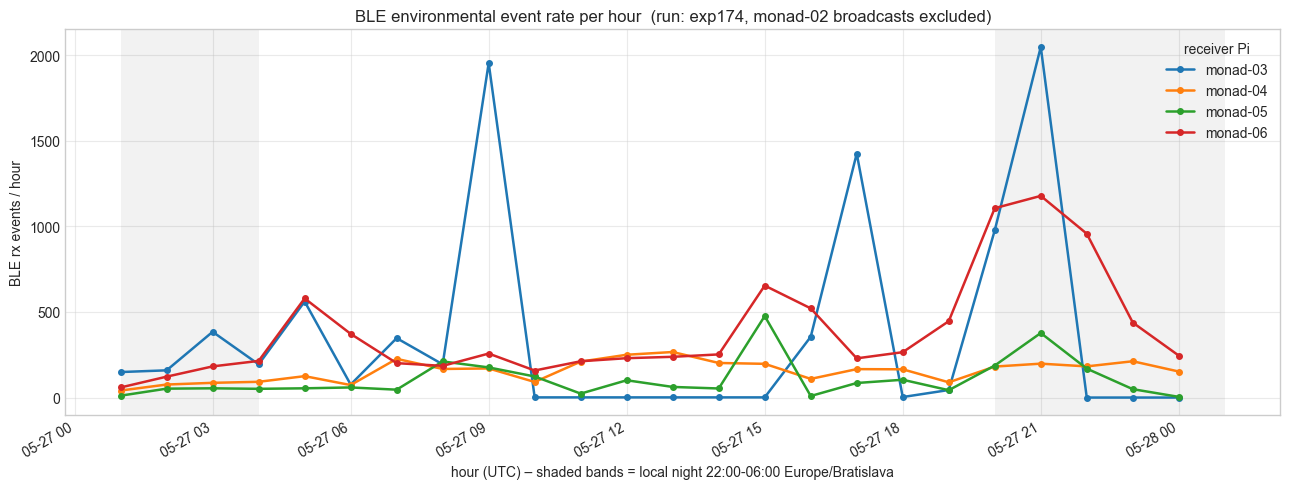

In [22]:
# ── Graph 1: Hourly BLE event rate per receiver Pi (monad-02 removed) ──
if not ble_env.empty:
    work = ble_env.copy()
    work["hour_utc"] = work["rx_ts_est"].dt.floor("h")
    rate = work.groupby(["hour_utc", "rx_pi_id"]).size().rename("events").reset_index()
    pivot = rate.pivot(index="hour_utc", columns="rx_pi_id", values="events").fillna(0).sort_index()
    pivot.to_csv(TABLES_DIR / "ble_env_hourly_event_rate.csv")

    fig, ax = plt.subplots(figsize=(13, 5))
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], marker="o", markersize=4, linewidth=1.8, label=col)

    # Shade local night (22:00 → 06:00 Bratislava) so the diurnal pattern is obvious.
    local_idx = pivot.index.tz_convert(LOCAL_TZ)
    in_night = (local_idx.hour >= 22) | (local_idx.hour < 6)
    for ts, night in zip(pivot.index, in_night):
        if night:
            ax.axvspan(ts, ts + pd.Timedelta("1h"), color="#222", alpha=0.06, lw=0)

    ax.set_title(f"BLE environmental event rate per hour  (run: {RUN_ID}, monad-02 broadcasts excluded)")
    ax.set_xlabel("hour (UTC) – shaded bands = local night 22:00-06:00 Europe/Bratislava")
    ax.set_ylabel("BLE rx events / hour")
    ax.legend(title="receiver Pi", loc="upper right")
    ax.grid(True, alpha=0.4)
    fig.autofmt_xdate()
    plt.tight_layout()
    savefig("ble_env_hourly_event_rate")
    display(pivot.tail(8))
else:
    print("ble_env empty - skipping hourly rate plot.")

,rx_pi_id,unique_devices
0,monad-03,1615
1,monad-04,570
2,monad-05,272
3,monad-06,1154


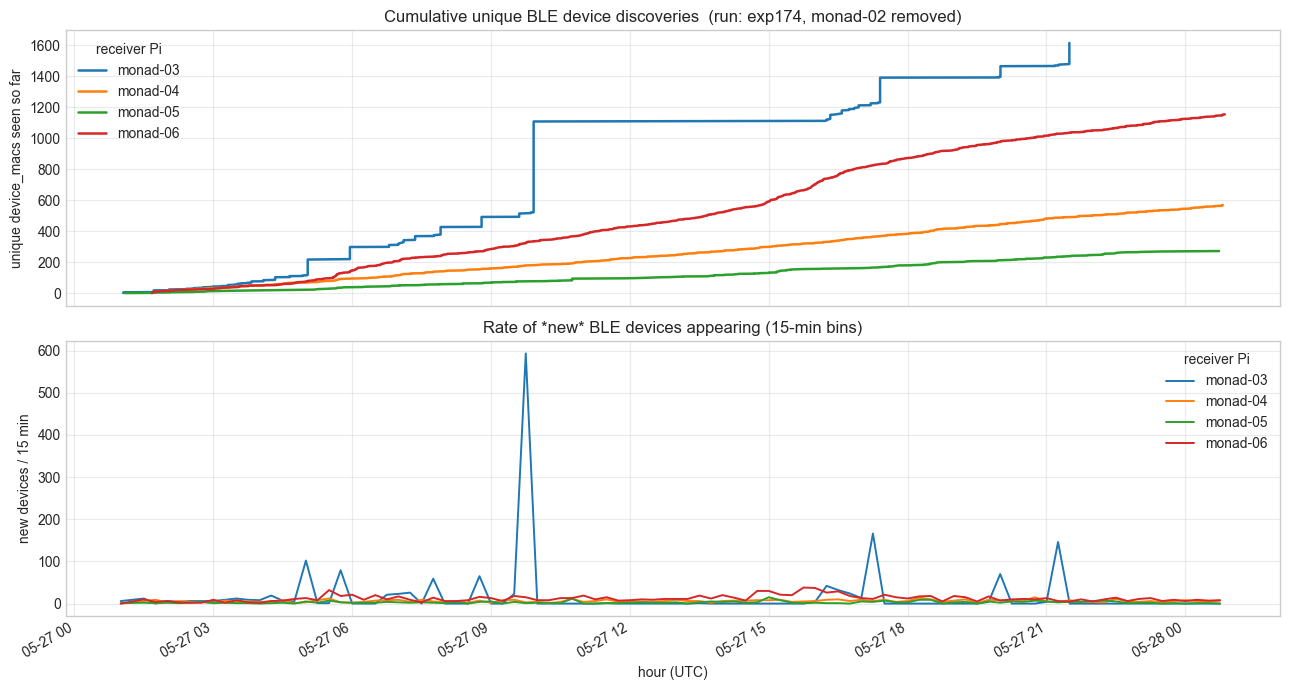

In [23]:
# ── Graph 2: Cumulative unique device discovery + 15-min new-device rate ──
if not ble_env.empty:
    work = ble_env[["rx_ts_est", "rx_pi_id", "device_mac"]].dropna().sort_values("rx_ts_est").copy()

    # First sighting per (Pi, device_mac)
    first = work.drop_duplicates(["rx_pi_id", "device_mac"]).copy()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    for pi, grp in first.groupby("rx_pi_id"):
        grp = grp.sort_values("rx_ts_est")
        ax1.plot(grp["rx_ts_est"], np.arange(1, len(grp) + 1), linewidth=1.8, label=pi)

    ax1.set_title(f"Cumulative unique BLE device discoveries  (run: {RUN_ID}, monad-02 removed)")
    ax1.set_ylabel("unique device_macs seen so far")
    ax1.grid(True, alpha=0.4)
    ax1.legend(title="receiver Pi")

    bucket = "15min"
    first["bucket"] = first["rx_ts_est"].dt.floor(bucket)
    new_per_bucket = (
        first.groupby(["bucket", "rx_pi_id"]).size().rename("new_devices").reset_index()
        .pivot(index="bucket", columns="rx_pi_id", values="new_devices").fillna(0).sort_index()
    )
    new_per_bucket.to_csv(TABLES_DIR / "ble_env_new_devices_15min.csv")
    new_per_bucket.plot(ax=ax2, linewidth=1.4)
    ax2.set_title(f"Rate of *new* BLE devices appearing (15-min bins)")
    ax2.set_xlabel("hour (UTC)")
    ax2.set_ylabel("new devices / 15 min")
    ax2.grid(True, alpha=0.4)
    ax2.legend(title="receiver Pi", loc="upper right")

    fig.autofmt_xdate()
    plt.tight_layout()
    savefig("ble_env_unique_device_discovery")

    totals = first.groupby("rx_pi_id")["device_mac"].nunique().rename("unique_devices").reset_index()
    display(totals)
else:
    print("ble_env empty - skipping cumulative discovery plot.")

hour_local,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
rx_pi_id,,,,,,,,,,,,,,,,,,,,,,,,
monad-03,0.0,0.0,0.0,149.0,159.0,384.0,194.0,561.0,76.0,347.0,194.0,1954.0,1.0,1.0,1.0,1.0,1.0,1.0,355.0,1425.0,3.0,44.0,977.0,2048.0
monad-04,182.0,212.0,152.0,41.0,76.0,86.0,92.0,125.0,73.0,226.0,167.0,170.0,91.0,210.0,250.0,266.0,202.0,197.0,109.0,166.0,165.0,89.0,181.0,198.0
monad-05,169.0,49.0,4.0,11.0,52.0,54.0,51.0,54.0,59.0,46.0,211.0,176.0,123.0,23.0,101.0,62.0,53.0,476.0,9.0,85.0,104.0,43.0,187.0,377.0
monad-06,957.0,438.0,245.0,59.0,122.0,182.0,214.0,579.0,372.0,201.0,185.0,257.0,158.0,212.0,230.0,238.0,252.0,654.0,521.0,229.0,265.0,446.0,1106.0,1178.0


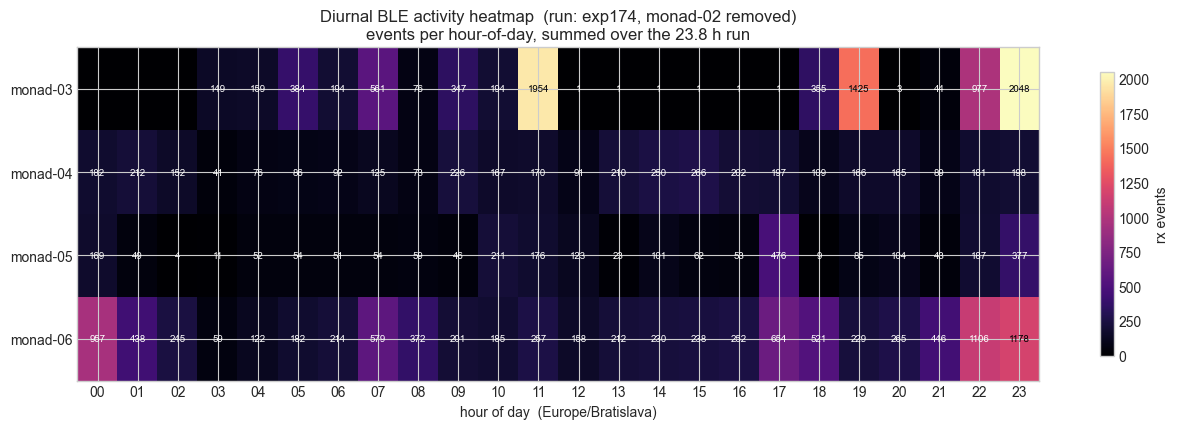

In [24]:
# ── Graph 3: Diurnal heatmap – hour-of-day (local) × receiver Pi ──
if not ble_env.empty:
    work = ble_env.dropna(subset=["hour_local", "rx_pi_id"]).copy()
    heat = (
        work.groupby(["rx_pi_id", "hour_local"]).size().rename("events").reset_index()
        .pivot(index="rx_pi_id", columns="hour_local", values="events").fillna(0)
    )
    heat = heat.reindex(columns=range(24), fill_value=0).sort_index()
    heat.to_csv(TABLES_DIR / "ble_env_diurnal_heatmap.csv")

    fig, ax = plt.subplots(figsize=(13, max(3, 0.6 * len(heat) + 2)))
    im = ax.imshow(heat.values, aspect="auto", cmap="magma", interpolation="nearest")
    ax.set_xticks(range(24))
    ax.set_xticklabels([f"{h:02d}" for h in range(24)])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel(f"hour of day  ({LOCAL_TZ})")
    ax.set_title(f"Diurnal BLE activity heatmap  (run: {RUN_ID}, monad-02 removed)\nevents per hour-of-day, summed over the {((ble_env['rx_ts_est'].max() - ble_env['rx_ts_est'].min()).total_seconds()/3600):.1f} h run")
    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("rx events")

    # Numeric annotations
    vmax = heat.values.max()
    for y in range(heat.shape[0]):
        for x in range(heat.shape[1]):
            v = heat.values[y, x]
            if v > 0:
                ax.text(x, y, f"{int(v)}", ha="center", va="center",
                        fontsize=7, color="white" if v < vmax * 0.55 else "black")
    plt.tight_layout()
    savefig("ble_env_diurnal_heatmap")
    display(heat)
else:
    print("ble_env empty - skipping diurnal heatmap.")

,close_events,total_events,close_devices
hour_local,,,
0,624,879,16
1,226,302,18
2,122,163,18
3,72,114,13
4,131,193,11
5,145,298,19
6,159,209,11
7,364,481,10
8,193,270,10


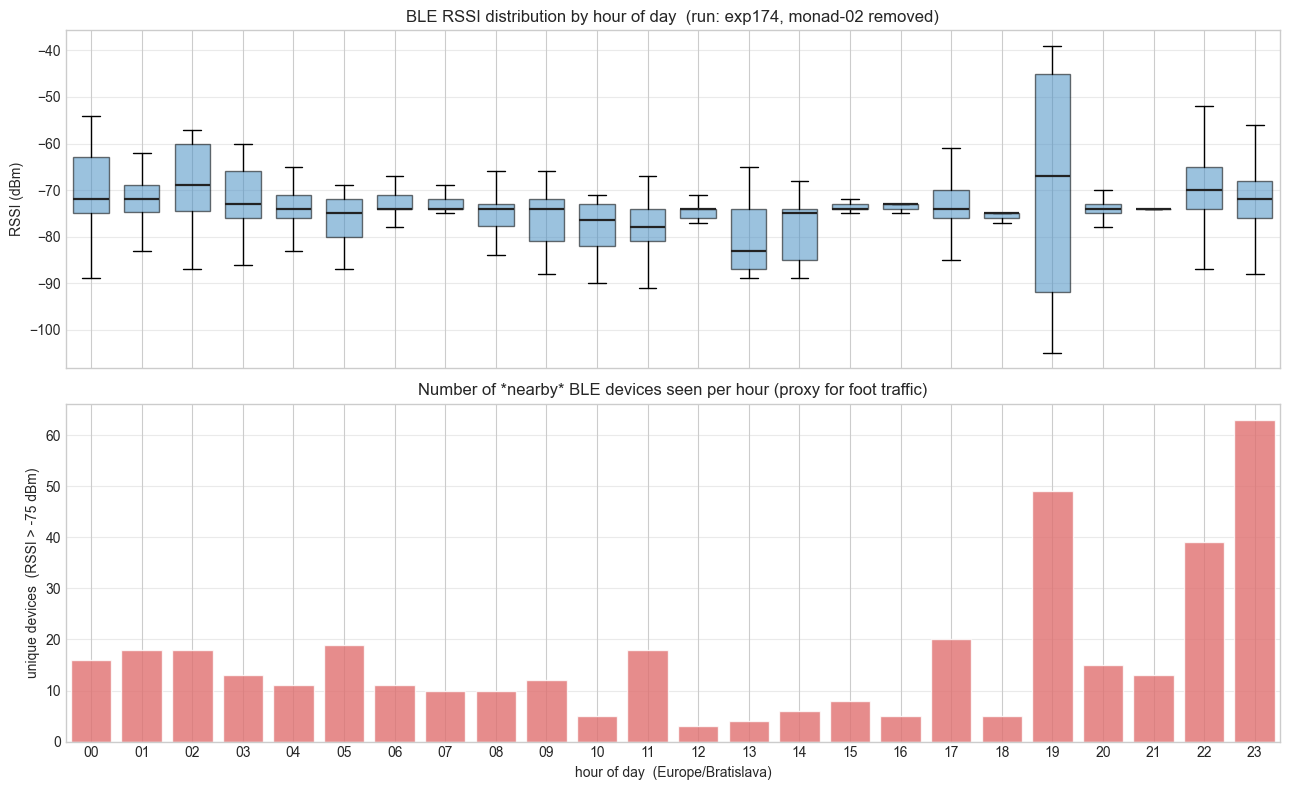

In [25]:
# ── Graph 4: RSSI distribution by hour of day + nearby-device count ──
if not ble_env.empty:
    rssi = ble_env.dropna(subset=["rssi_dbm", "hour_local"]).copy()
    rssi["rssi_dbm"] = pd.to_numeric(rssi["rssi_dbm"], errors="coerce")
    rssi = rssi.dropna(subset=["rssi_dbm"])

    if rssi.empty:
        print("No rows with rssi_dbm – skipping RSSI-by-hour plot.")
    else:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

        data_per_hour = [rssi.loc[rssi["hour_local"] == h, "rssi_dbm"].values for h in range(24)]
        # Boxplot of RSSI per hour-of-day
        bp = ax1.boxplot(data_per_hour, positions=range(24), widths=0.7,
                         patch_artist=True, showfliers=False)
        for patch in bp["boxes"]:
            patch.set_facecolor("#4a90c4"); patch.set_alpha(0.55)
        for med in bp["medians"]:
            med.set_color("#222"); med.set_linewidth(1.6)
        ax1.set_ylabel("RSSI (dBm)")
        ax1.set_title(f"BLE RSSI distribution by hour of day  (run: {RUN_ID}, monad-02 removed)")
        ax1.grid(True, axis="y", alpha=0.4)

        # Count of "close" devices (RSSI > -75 dBm) per hour
        close_thresh = -75.0
        close_per_hour = (
            rssi.assign(close=(rssi["rssi_dbm"] > close_thresh).astype(int))
            .groupby("hour_local")
            .agg(close_events=("close", "sum"),
                 total_events=("close", "size"),
                 close_devices=("device_mac", lambda s: s[rssi.loc[s.index, "rssi_dbm"] > close_thresh].nunique()))
            .reindex(range(24), fill_value=0)
        )
        close_per_hour.to_csv(TABLES_DIR / "ble_env_close_devices_by_hour.csv")
        ax2.bar(close_per_hour.index, close_per_hour["close_devices"],
                color="#e07070", alpha=0.8, edgecolor="white")
        ax2.set_xticks(range(24))
        ax2.set_xticklabels([f"{h:02d}" for h in range(24)])
        ax2.set_xlabel(f"hour of day  ({LOCAL_TZ})")
        ax2.set_ylabel(f"unique devices  (RSSI > {close_thresh:.0f} dBm)")
        ax2.set_title("Number of *nearby* BLE devices seen per hour (proxy for foot traffic)")
        ax2.grid(True, axis="y", alpha=0.4)

        plt.tight_layout()
        savefig("ble_env_rssi_by_hour")
        display(close_per_hour)
else:
    print("ble_env empty - skipping RSSI-by-hour plot.")

## Power Statistics

Power data should come from Prometheus/Mimir exports or agent status metrics. The AX210 approximation uses `(3V3_SYS current - baseline) * 3V3_SYS voltage`.

In [26]:
POWER_BASELINE_A = float(metadata.get("pi_3v3_baseline_a", 0.084))
power_summary = {}

if power.empty:
    print("No power_timeseries.csv yet. Export monad_pi_* power series from Mimir/Prometheus into this file.")
else:
    work = power.copy()
    if {"pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v"}.issubset(work.columns):
        work["ax210_power_w_est"] = (work["pmic_3v3_sys_current_a"] - POWER_BASELINE_A).clip(lower=0) * work["pmic_3v3_sys_voltage_v"]
        power_summary["ax210_power_w_mean"] = float(work["ax210_power_w_est"].mean())
        power_summary["ax210_power_w_p95"] = float(work["ax210_power_w_est"].quantile(0.95))
    if "under_voltage" in work.columns:
        power_summary["under_voltage_samples"] = int((work["under_voltage"].fillna(0) > 0).sum())
    work.to_csv(TABLES_DIR / "power_with_ax210_estimate.csv", index=False)
    display(pd.Series(power_summary))

No power_timeseries.csv yet. Export monad_pi_* power series from Mimir/Prometheus into this file.


In [27]:
if not power.empty and "timestamp" in power.columns:
    plot_cols = [c for c in ["pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v", "ax210_power_w_est", "cpu_temp_c"] if c in power.columns]
    plot_power = pd.read_csv(TABLES_DIR / "power_with_ax210_estimate.csv") if (TABLES_DIR / "power_with_ax210_estimate.csv").exists() else power
    plot_power["timestamp"] = pd.to_datetime(plot_power["timestamp"], utc=True, errors="coerce")
    plot_cols = [c for c in ["pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v", "ax210_power_w_est", "cpu_temp_c"] if c in plot_power.columns]
    if plot_cols:
        ax = plot_power.set_index("timestamp")[plot_cols].plot(subplots=True, figsize=(12, 7), sharex=True)
        savefig("power_timeseries")
else:
    print("Skipping power time-series plot until power data exists.")

Skipping power time-series plot until power data exists.


## Export Key Numbers

This block creates a compact summary that can be pasted into a report or used as thesis appendix input.

In [28]:
key_numbers = {
    "run_id": metadata.get("run_id", RUN_ID),
    "experiment_id": metadata.get("experiment_id", ""),
    **wifi_summary,
    **ble_summary,
    **power_summary,
}

with (TABLES_DIR / "key_numbers.json").open("w", encoding="utf-8") as fh:
    json.dump(key_numbers, fh, indent=2, sort_keys=True)

pd.Series(key_numbers)

run_id                       exp174
experiment_id                exp174
wifi_frame_count           20509870
wifi_distinct_src_macs        14680
wifi_distinct_bssids           1350
wifi_channels_seen               24
wifi_percent_intel              0.0
ble_rx_count                  47670
ble_distinct_adv_ids_rx       10226
dtype: object